In [2]:
import numpy as np
import matplotlib.pyplot as plt

**1) Base de Lagrange**

Dans votre rapport:
- Afficher les figures pour les bases de Lagrange de degrées 1, 2 et 3 (2, 3 et 4 noueds).

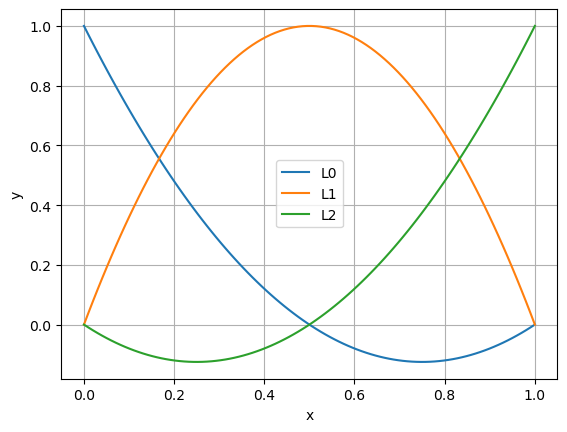

In [21]:
def base_lagrange(i,Xi,X):
    # Code manquant

    return Li 


x = np.linspace(0.0, 1.0, 100)
x_nodes = np.array([0.,0.5,1.0])

for i in range(3):
    plt.plot(x, base_lagrange(i, x_nodes,x), label= 'L{0}'.format(i))
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

**2) Interpolation de Lagrange**

Votre rapport devra contenir:
- Une figure d'exemple d'une interpolation ayant 6 noueds de collocations, y(x) étant donné par une fonction mathématique de votre préférence. Pour cela, remplacez y_nodes par l'application de cette fonction mathématique sous x_nodes. N'oubliez de labelliser vos axes, contruire une légende et un titre avec l'expression de la fonction choisi par exemple.

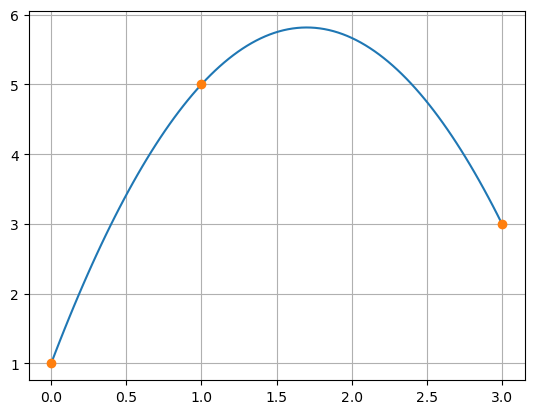

In [22]:
def lagrange_poly(Xi,Yi,X):
    p = 0.
    for i in range(len(Xi)):
        Li = base_lagrange(i,Xi,X)
        p += Yi[i]*Li

    return p

# la keyword class permet de construire une classe (équivalent à Struct en MATLAB, Type en FORTRAN, etc)
# La méthode __init__ permets d'initaliser l'objet de la classe. Elle sera appellé quand nom de la classe est utilisé
class LagrangePoly:
    def __init__(self, Xi, Yi):
        self.deg = len(Xi)-1
        self.Xi = Xi
        self.Yi = Yi

    def __call__(self, x):
        return lagrange_poly(self.Xi,self.Yi,x)

# Test    
x = np.linspace(0.0,3.0, 100)
x_nodes = np.array([0.,1.0,3.0])
y_nodes = np.array([1.0,5.0,3.0])
p = LagrangePoly(x_nodes,y_nodes)
plt.plot(x,p(x))
plt.plot(x_nodes, y_nodes, 'o')
plt.grid()

**3) Etude d'erreur de l'interpolation donné par un fichier externe**

Le votre rapport devra contenir pour chaque fichier de données (Data1.txt, Data2.txt, Data3.txt)
- a) Une figure affichant les donnés et les fonctions d'interpolation pour un certain range de nombre de noeuds (choisi par vous-même)
- b) Une figure d'erreur en fonction du nombre de noeuds. En particulier, vous devez choisir un nombre de noueds maximal qui vous permettra de voir la degradation des erreurs quand le nombre de noeuds est grand (pourqoui?). La figure a) doit être dans la même plage de noueds que b). 


D'abord on va lire les données stockées dans un fichier

Text(0, 0.5, 'y')

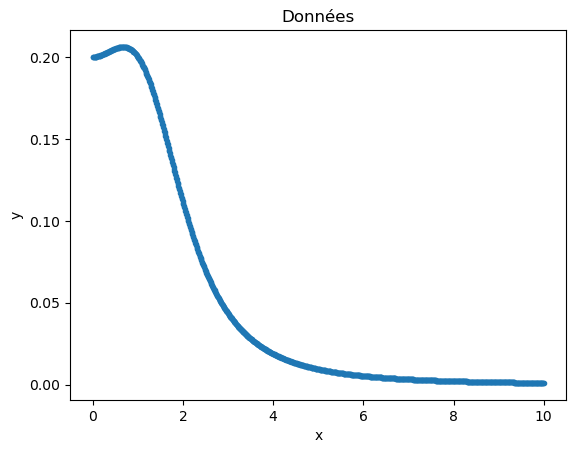

In [27]:
XY = np.loadtxt('Data0.txt')

# figure
plt.title("Données")
plt.plot(XY[:,0],XY[:,1],'.')
plt.xlabel('x')
plt.ylabel('y')

Ensuite, on va stocker les polynômes d'interpolation dans une liste

In [17]:
min_nodes = 3
max_nodes = 15
poly_list = []

for k in range(min_nodes,max_nodes+1,2):
    ii = np.linspace(0,len(XY)-1,k).astype('int')            # Position of the nodes in the data vector
    XYii=XY[ii,:]    # XY values of the nodes
    poly_list.append(LagrangePoly(XYii[:,0],XYii[:,1]))

On affiche les polynômes de interpolation

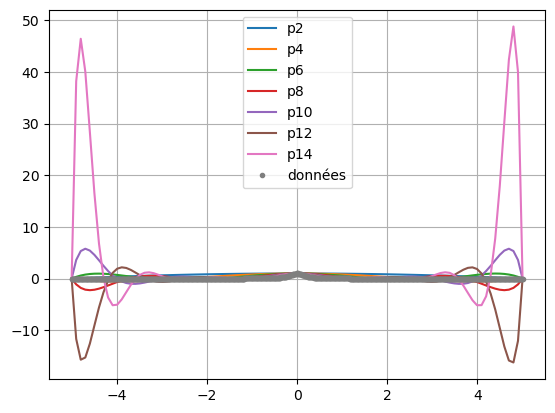

In [18]:
x = np.linspace(np.min(XY[:,0]), np.max(XY[:,0]), 100)

for p in poly_list:
    plt.plot(x,p(x), label = 'p{0}'.format(p.deg))

plt.plot(XY[:,0],XY[:,1], '.', label = 'données')
plt.legend(loc='best')
plt.grid()
# plt.savefig(nom de la figure)

On calcule et affiche les erreurs absolus commits

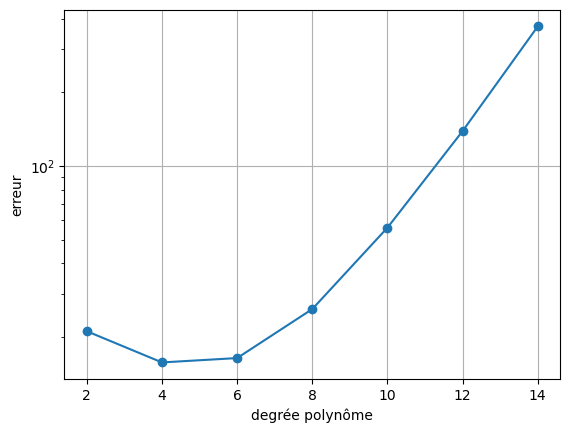

In [19]:
error = []
for p in poly_list:
    error.append(np.linalg.norm(p(XY[:,0]) - XY[:,1]))

plt.plot([p.deg for p in poly_list], error, '-o')
plt.ylabel('erreur')
plt.yscale('log')
plt.xlabel('degrée polynôme')
plt.grid()

**4) Noeuds de Chebyshev**

Dans l'intervale $[a,b]$ les noueds de Chebyshev sont définis par:
$$ x_j = \frac{b-a}{2}\cos(\frac{\pi(2j+1)}{2N})+\frac{a+b}{2}, \quad j=0,1, \dots, N-1 .$$

Pour le rapport vous devez:
- Programmer la fonction chebyshev_nodes(a,b,N) que retourne un np.array contenant les noeuds de Chebyshev (au-dessous). Utilisez np.sort pour avoir une ordre croissant des points.
- Faire les mêmes analyses de 3) pour le Data2.txt en utilisant ces nouveaux noeuds. 

In [20]:
def chebyshev_nodes(a,b,N):
    # complétez
    return Xi

# Test
print(chebyshev_nodes(-1.0,1.0,9))

NameError: name 'Xi' is not defined

Comme les noueds de Chebyshev ne seront pas exactement les mêmes disponibles dans le fichier de donnée, la fonction suivant retourne les indexes $i$ du vecteur $\bf x$ tels que $x_i$ est le plus proche d'un certain noeud de Chebyshev   

In [10]:
def closest_nodes_index(nodes, x):
    ii = []
    for xi in nodes:
        ii.append(np.argmin(np.abs(x-xi)))

    return np.array(ii) 

In [11]:
min_nodes = 3
max_nodes = 30
poly_list = []

for k in range(min_nodes,max_nodes+1,2):
    cheb_nodes = chebyshev_nodes(np.min(XY[:,0]), np.max(XY[:,0]), k)  # Position of the nodes in the data vector
    ii = closest_nodes_index(cheb_nodes, XY[:,0])
    XYii=XY[ii,:]    # XY values of the nodes
    poly_list.append(LagrangePoly(XYii[:,0],XYii[:,1]))

NameError: name 'XY' is not defined

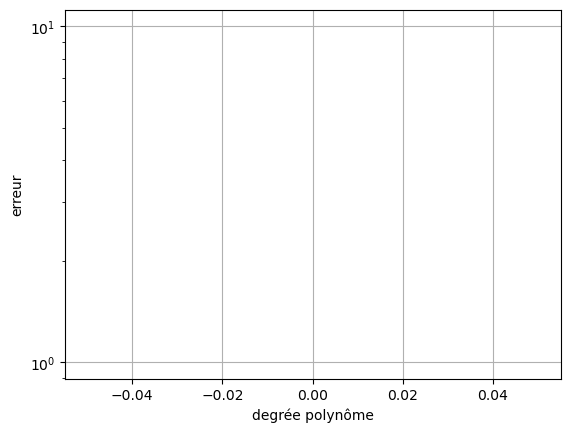

In [12]:
error = []
for p in poly_list:
    error.append(np.linalg.norm(p(XY[:,0]) - XY[:,1]))

plt.plot([p.deg for p in poly_list], error, '-o')
plt.ylabel('erreur')
plt.yscale('log')
plt.xlabel('degrée polynôme')
plt.grid()

In [13]:
x = np.linspace(np.min(XY[:,0]), np.max(XY[:,0]), 100)

for p in poly_list:
    plt.plot(x,p(x), label = 'p{0}'.format(p.deg))

plt.plot(XY[:,0],XY[:,1], '.', label = 'données')
plt.legend(loc='best')
plt.grid()

NameError: name 'XY' is not defined

**5) **

Remplacez le Data2.txt par la fonction de Runge $f(x) = \frac{1}{1+25 x^2}$. Maintenant les noeuds pourront être echantionnés de façon exacte. Qu'est-ce que ce passe avec les erreurs de 4)?